# 深度学习 HW01

学号：20234080324  
姓名：李英华

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_blobs
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)

## 2 概述、线性代数和 NDArray

### 2.1 理论题

已知

$$
a=\begin{bmatrix}2\\-1\\3\end{bmatrix},\quad
b=\begin{bmatrix}1\\4\\-2\end{bmatrix},\quad
A=\begin{bmatrix}1&0&2\\-1&3&1\end{bmatrix},\quad
B=\begin{bmatrix}2&1\\0&-1\\3&2\end{bmatrix}.
$$

1. 向量点积：

$$
a\cdot b = 2\times1 + (-1)\times4 + 3\times(-2) = -8.
$$

2. 矩阵乘法：

$$
AB=\begin{bmatrix}8&5\\1&-2\end{bmatrix},\quad \text{shape}=(2,2).
$$

3. Frobenius 范数：

$$
\|a\|_F = \sqrt{2^2+(-1)^2+3^2}=\sqrt{14}.
$$

In [2]:
X = np.random.randn(3, 4)
Y = np.ones((4, 2))
Z = X @ Y

print("X =\n", X)
print("\nY =\n", Y)
print("\nZ =\n", Z)
print("\nZ[0, 1] =", Z[0, 1])
print("Z[1, :] =", Z[1, :])
print("||Z||_F =", np.linalg.norm(Z, ord="fro"))

X =
 [[ 0.4967 -0.1383  0.6477  1.523 ]
 [-0.2342 -0.2341  1.5792  0.7674]
 [-0.4695  0.5426 -0.4634 -0.4657]]

Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z =
 [[ 2.5292  2.5292]
 [ 1.8784  1.8784]
 [-0.8561 -0.8561]]

Z[0, 1] = 2.5291682463487657
Z[1, :] = [1.8784 1.8784]
||Z||_F = 4.616873319476863


## 3 概率与统计

### 3.1 理论题

设 $D$ 表示患病，$+$ 表示检测阳性。已知

$$
P(D)=0.001,\quad P(+|D)=0.99,\quad P(+|D^c)=0.02.
$$

由全概率公式，

$$
P(+)=0.99\times0.001+0.02\times0.999=0.02097.
$$

由贝叶斯公式，

$$
P(D|+) = \frac{P(+|D)P(D)}{P(+)}
= \frac{0.99\times0.001}{0.02097}
\approx 0.0472.
$$

因此，检测为阳性后真正患病的概率约为 **4.72%**。

实际方差 = 8.314169733144293e-06
理论方差 = 8.333333333333332e-06


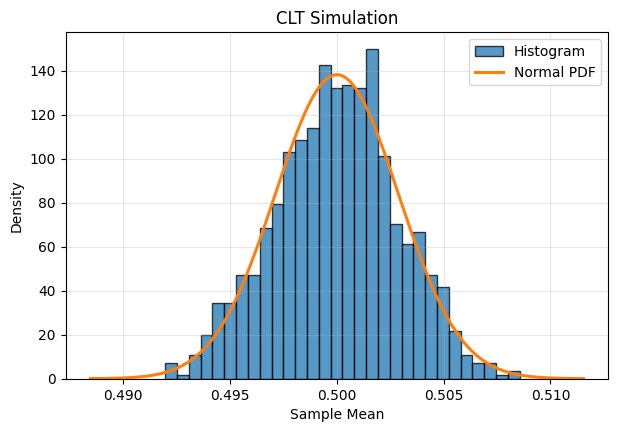

In [3]:
n = 10000
m = 1000

samples = np.random.uniform(0, 1, size=(m, n))
means = samples.mean(axis=1)

mu = 0.5
var_theory = (1 / 12) / n
sigma = np.sqrt(var_theory)
var_actual = np.var(means, ddof=0)

print("实际方差 =", var_actual)
print("理论方差 =", var_theory)

x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 400)
pdf = 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

plt.figure(figsize=(7, 4.5))
plt.hist(means, bins=30, density=True, alpha=0.75, edgecolor="black", label="Histogram")
plt.plot(x, pdf, linewidth=2.2, label="Normal PDF")
plt.title("CLT Simulation")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4 导数、反向传播和复杂度

### 4.1 理论题

给定

$$
z=(w_1x_1+w_2x_2-y)^2,\quad x_1=2,\ x_2=1,\ y=3.
$$

则

$$
\frac{\partial z}{\partial w_1}=2(w_1x_1+w_2x_2-y)x_1,
\qquad
\frac{\partial z}{\partial w_2}=2(w_1x_1+w_2x_2-y)x_2.
$$

代入 $x_1=2,\ x_2=1$，

$$
\frac{\partial z}{\partial w_1}=4(2w_1+w_2-3),\qquad
\frac{\partial z}{\partial w_2}=2(2w_1+w_2-3).
$$

当 $w_1=0.5,\ w_2=1$ 时，

$$
\frac{\partial z}{\partial w_1}=-4,\qquad
\frac{\partial z}{\partial w_2}=-2.
$$

In [4]:
x = 2.0
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b ** 2

grad_w1 = 2 * b * x
grad_w2 = 2 * b

print("a =", a)
print("b =", b)
print("L =", L)
print("manual dL/dw1 =", grad_w1)
print("manual dL/dw2 =", grad_w2)

def forward(w1_value, w2_value):
    return (x * w1_value + w2_value) ** 2

try:
    import torch

    w1_t = torch.tensor(1.5, requires_grad=True)
    w2_t = torch.tensor(0.5, requires_grad=True)
    L_t = (x * w1_t + w2_t) ** 2
    L_t.backward()
    check_w1 = w1_t.grad.item()
    check_w2 = w2_t.grad.item()
    method = "torch.autograd"
except ModuleNotFoundError:
    eps = 1e-6
    check_w1 = (forward(w1 + eps, w2) - forward(w1 - eps, w2)) / (2 * eps)
    check_w2 = (forward(w1, w2 + eps) - forward(w1, w2 - eps)) / (2 * eps)
    method = "numerical gradient"

print("check method =", method)
print("check dL/dw1 =", check_w1)
print("check dL/dw2 =", check_w2)
print("consistent =", np.allclose([grad_w1, grad_w2], [check_w1, check_w2], atol=1e-5))

a = 3.0
b = 3.5
L = 12.25
manual dL/dw1 = 14.0
manual dL/dw2 = 7.0
check method = torch.autograd
check dL/dw1 = 14.0
check dL/dw2 = 7.0
consistent = True


## 5 线性方法、基础优化和 Softmax 回归

### 5.1 理论题

线性回归模型为

$$
\hat y_i = wx_i + b.
$$

损失函数

$$
L=\frac{1}{n}\sum_{i=1}^{n}\left(y_i-(wx_i+b)\right)^2.
$$

因此

$$
\frac{\partial L}{\partial w}
=\frac{2}{n}\sum_{i=1}^{n}\big((wx_i+b)-y_i\big)x_i,
$$

$$
\frac{\partial L}{\partial b}
=\frac{2}{n}\sum_{i=1}^{n}\big((wx_i+b)-y_i\big).
$$

In [5]:
digits = load_digits()
X = digits.data / 16.0
y = digits.target
Y = np.eye(10)[y]

X_train, X_test, Y_train, Y_test, y_train, y_test = train_test_split(
    X, Y, y, test_size=0.2, random_state=42, stratify=y
)

n_features = X_train.shape[1]
W = 0.01 * np.random.randn(n_features, 10)
b = np.zeros((1, 10))

def softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    eps = 1e-12
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))

lr = 0.1
batch_size = 32
epochs = 50
n_train = X_train.shape[0]

for _ in range(epochs):
    indices = np.random.permutation(n_train)
    X_shuf = X_train[indices]
    Y_shuf = Y_train[indices]

    for start in range(0, n_train, batch_size):
        xb = X_shuf[start:start + batch_size]
        yb = Y_shuf[start:start + batch_size]

        probs = softmax(xb @ W + b)
        grad_logits = (probs - yb) / xb.shape[0]
        grad_W = xb.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)

        W -= lr * grad_W
        b -= lr * grad_b

train_probs = softmax(X_train @ W + b)
test_probs = softmax(X_test @ W + b)

train_loss = cross_entropy(train_probs, Y_train)
test_acc = np.mean(np.argmax(test_probs, axis=1) == y_test)

print("train loss =", train_loss)
print("test accuracy =", test_acc)

train loss = 0.18067754094926614
test accuracy = 0.95


## 6 最大似然估计和逻辑回归

### 6.1 理论题

若 $x_1,\dots,x_n \overset{i.i.d.}{\sim} N(\mu,\sigma^2)$，则似然函数为

$$
L(\mu,\sigma^2)=\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)^n
\exp\left(-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2\right).
$$

取对数似然并分别对 $\mu,\sigma^2$ 求偏导，令其为 0，可得

$$
\hat\mu=\frac{1}{n}\sum_{i=1}^{n}x_i,
\qquad
\hat\sigma^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2.
$$

test accuracy = 1.0
final loss = 0.003864991687099007


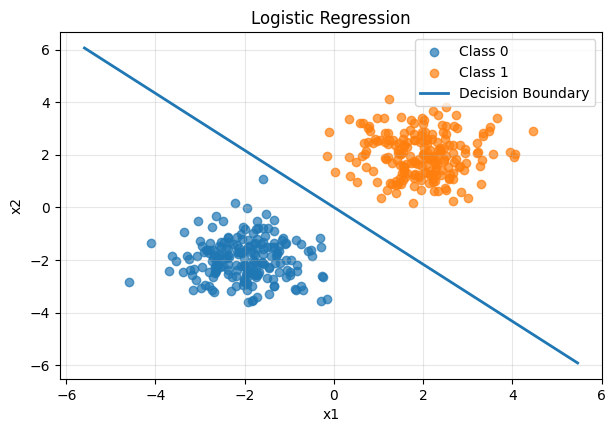

In [6]:
centers = [(-2, -2), (2, 2)]
cluster_std = 0.8

X_train, y_train = make_blobs(
    n_samples=[200, 200],
    centers=centers,
    cluster_std=cluster_std,
    n_features=2,
    random_state=42,
)
y_train = y_train.reshape(-1, 1)

X_test, y_test = make_blobs(
    n_samples=[50, 50],
    centers=centers,
    cluster_std=cluster_std,
    n_features=2,
    random_state=123,
)
y_test = y_test.reshape(-1, 1)

def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_hat, y_true):
    eps = 1e-12
    return -np.mean(y_true * np.log(y_hat + eps) + (1 - y_true) * np.log(1 - y_hat + eps))

w = np.zeros((2, 1))
b = 0.0
lr = 0.1
epochs = 1000

for _ in range(epochs):
    y_hat = sigmoid(X_train @ w + b)
    dw = (X_train.T @ (y_hat - y_train)) / X_train.shape[0]
    db = np.mean(y_hat - y_train)
    w -= lr * dw
    b -= lr * db

test_prob = sigmoid(X_test @ w + b)
test_pred = (test_prob >= 0.5).astype(int)
test_acc = np.mean(test_pred == y_test)

print("test accuracy =", test_acc)
print("final loss =", binary_cross_entropy(sigmoid(X_train @ w + b), y_train))

plt.figure(figsize=(7, 4.5))
plt.scatter(X_train[y_train[:, 0] == 0, 0], X_train[y_train[:, 0] == 0, 1], alpha=0.7, label="Class 0")
plt.scatter(X_train[y_train[:, 0] == 1, 0], X_train[y_train[:, 0] == 1, 1], alpha=0.7, label="Class 1")

xs = np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, 200)
ys = -(w[0, 0] * xs + b) / w[1, 0]
plt.plot(xs, ys, linewidth=2, label="Decision Boundary")

plt.title("Logistic Regression")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()